In [27]:
from IPython.display import Image, display

# BASIC OF PYCAIRO

## What is PyCairo

- ⁡⁣⁣⁢PyCairo⁡ is a Python library for 2D graphics.
- It provides Python bindings for the Cairo graphics library, which allows you to create vector-based graphics that can be rendered to various output formats, such as PNG images, PDF files, SVG files, or directly to a window or surface.
- We can install PyCairo by running the following pip command in terminal:

In [28]:
pip install pycairo

Note: you may need to restart the kernel to use updated packages.


## Simple Image with PyCairo

Every image is divided into two parts:
- Surface (canvas)
- Drawing

To use PyCairo we create a ⁡⁣⁣⁢𝘀𝘂𝗿𝗳𝗮𝗰𝗲⁡ to draw on.
- A surface is an object where we create our image.
- When creating an image we need to specify:
  - type of output: PNG, PDF, SVG
  - image format: FORMAT_RGB24
  - image size: (width, length)

The surface has inverted axes that can be as shown below
<pre>
--------------------------->x-axis
|
|
|
|
|
|
|
↓↓
y-axis
</pre>

After creating a surface we need to create a ⁡⁣⁣⁢𝗰𝗼𝗻𝘁𝗲𝘅𝘁⁡.
- A context is a tool we use to draw on our surface.

Lastly, we use our context tool to paint/fill the surface with a color using the `.paint()` function.

Import the PyCairo library using the line below

In [29]:
import cairo

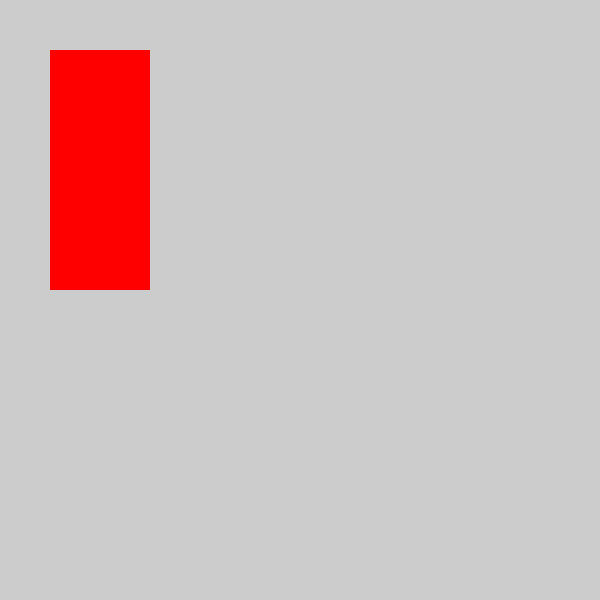

In [30]:
# 1. 𝕊𝕖𝕥𝕥𝕚𝕟𝕘 𝕦𝕡 𝕒 𝕤𝕦𝕣𝕗𝕒𝕔𝕖
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600) 
# PARAMETERS: output type (ImageSurface == png)
# ,format, width, length

# 2. 𝕊𝕖𝕥𝕦𝕡 𝕒 𝕓𝕣𝕦𝕤𝕙 𝕒𝕜𝕒 𝕔𝕠𝕟𝕥𝕖𝕩𝕥
context = cairo.Context(surface)
# takes the surface/canvas as argument
context.set_source_rgb(0.8, 0.8, 0.8)
# pick color of surface with rgb values
context.paint()
# set paint color on surface

# 3. 𝔻𝕣𝕒𝕨 𝕒𝕟 𝕚𝕞𝕒𝕘𝕖
context.rectangle(50,50,100,240)
# give coordinates and dimensions
context.set_source_rgb(1,0,0)
# pick color of rectangle with rgb values
context.fill()
# set paint to fill rectangle

surface.write_to_png('Images/1.basics.png')
display(Image(filename='Images/1.basics.png'))

## Using Fill and Stroke

Fill is used to fill an image/shape with a specific color while Stroke is used to outline a shape/image with a specific color.
- Fill uses the `.fill()` function
- Stroke uses the `.stroke()` function

To incorporte both fill and stroke in a shape/image we need to use the `fill_preserve()` function to fill the image with specific color then use the `.stroke()` to outline it with the specific color. We can also set the line width using the `.set_line_width()` function.
- Fill uses the `.fill_preserve()` function
- Stroke uses the `.stroke()` function

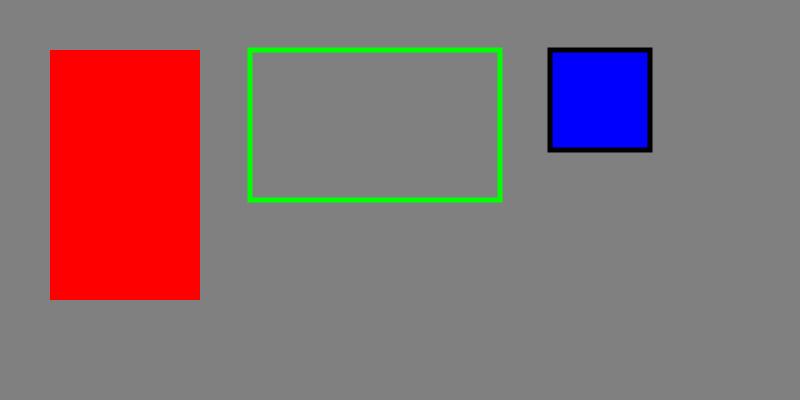

In [31]:
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 800, 400)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.5, 0.5, 0.5)
ctx.paint()

# Red rectangle - fill only
ctx.rectangle(50, 50, 150, 250)
ctx.set_source_rgb(1, 0, 0)
ctx.fill()

# Green rectangle - stroke only
ctx.rectangle(250, 50, 250, 150)
ctx.set_source_rgb(0,1,0)
ctx.set_line_width(5) # need to set a line width if using stoke
ctx.stroke()

# Blue square - fill and stroke
ctx. rectangle(550, 50, 100, 100)
ctx.set_source_rgb(0,0,1)
ctx.fill_preserve() # set to fill preserve to have fill then describe the stroke 
ctx.set_source_rgb(0,0,0) # set color for stroke separately
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/2.fill_stroke.png')
display(Image(filename='Images/2.fill_stroke.png'))

## Open and Closed Shapes

Pycairo uses the idea of a current point when drawing shapes. This makes it easy to create common shapes, such as polygons, which are formed through the end-to-end joining of lines or curves.

Initially the path is empty and the current point is undefined so we have to set it using the `.move_to()` function. The next point is designated using the `.line_to()` function.

After points on a line have been set, we set the color and width and use `.stroke()` to draw it.

In [32]:
# Clear the surface
ctx.set_source_rgb(1, 1, 1) 
ctx.paint()

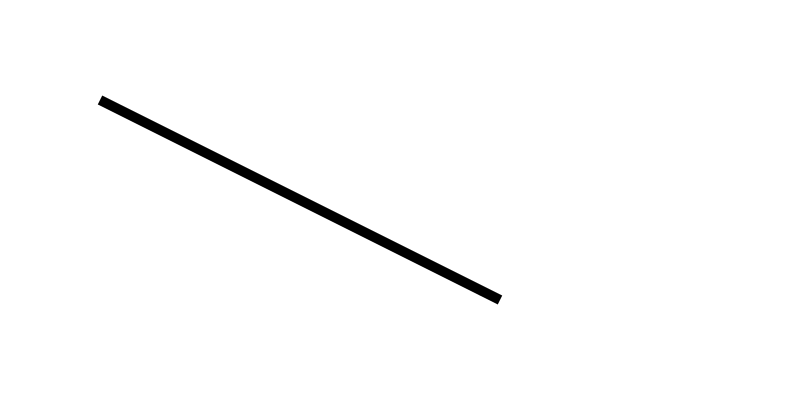

In [33]:
# Drawing lines
ctx.move_to(100, 100) # setting start coordinate
ctx. line_to(500, 300) # setting other coordinates
ctx.set_source_rgb(0,0,0)
ctx.set_line_width(10)
ctx.stroke() # a it is a line use stroke

surface.write_to_png('Images/3.draw_line.png')
display(Image(filename='Images/3.draw_line.png'))

The above format can only be used to form an open shape which is mainly for decorative dividers and symbols as shown below. 

In [34]:
# Clear the surface
ctx.set_source_rgb(1, 1, 1) 
ctx.paint()

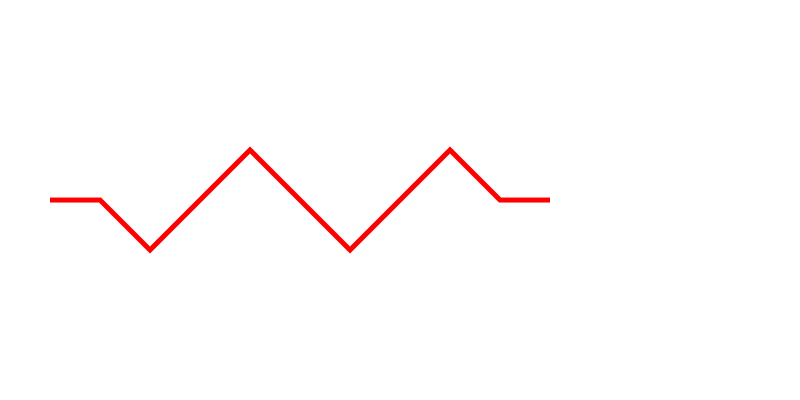

In [35]:
# Open polygon - decorative dividers, symbols, arrows
ctx.move_to(50, 200)
ctx.line_to(100, 200)
ctx.line_to(150, 250)
ctx.line_to(250, 150)
ctx.line_to(350, 250)
ctx.line_to(450, 150)
ctx.line_to(500, 200)
ctx.line_to(550, 200)
ctx.set_source_rgb(1,0,0)
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/4.open_shape.png')
display(Image(filename='Images/4.open_shape.png'))

In order to create closed shapes, we have to add the `.close_path()` function before we stroke the path. This will create a line from our current point to the starting point of the line.

We can this create our own complex shapes apart from PyCairo's predefined ones like rectangle {`.rectangle(x,y,w,l)`}

In [36]:
# Clear the surface
ctx.set_source_rgb(1, 1, 1) 
ctx.paint()

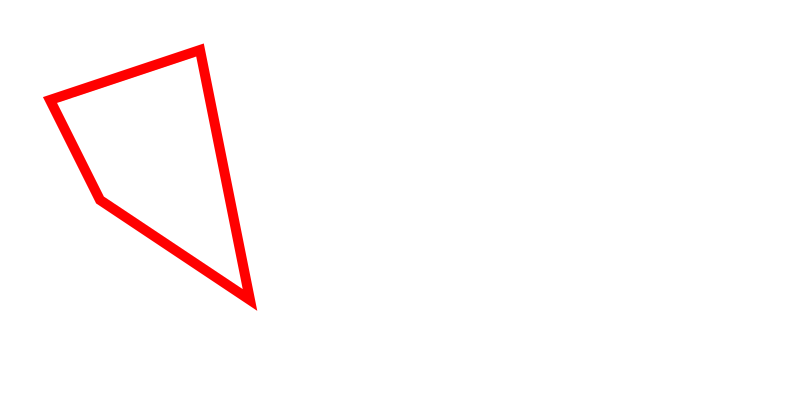

In [37]:
# Closed polygon
ctx.move_to(50, 100)  # A
ctx.line_to(200,50)   # B
ctx.line_to(250, 300) # C
ctx.line_to(100,200)  # D
ctx.close_path() # adds a line btn last point and first point in path
ctx.set_source_rgb(1,0,0)
ctx.set_line_width(10)
ctx.stroke()

surface.write_to_png('Images/5.closed_shape.png')
display(Image(filename='Images/5.closed_shape.png'))